# *Brain MR Image Synthesis with Latent Diffusion Models*

The aim of this notebook is to implement and validate a latent diffusion model (LDM) - taking inspiration from the original idea of Rombach et al.(https://arxiv.org/abs/2112.10752).

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*HCrIdrDRpRwNIbB7IwHqWg.png" width="600">


The data used is a 2D dataset of ~800 axial slices through ***neonatal*** brain MRI. The Gestational Age at scan (GA) of the individuals ranges from ~30 to 40 weeks. Each slice has an associated ground-truth label indicating the GA of each slice at scan time.


### Load and Create Dataset
#### Data Notes

- Data files can be downloaded from link in Readme it contains separate sub-folders for each of the train, validation and test splits and the labels for each subject can be found in ***'labels.pkl'***

In this first part I created a dataset and implemented image augmentation (Gaussian noise and rotation) to improve performance. I then displayed the two augmented images to validate that it is working.
- N.B. the augmentation dataset is created in a way that there is 40% chance that the image will have either gaussian noise or rotation applied to it)

In [1]:
import torch
from torch.utils.data import DataLoader
import nibabel as nib
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
import torchvision.transforms.functional as TF
import torchvision.transforms as T
import os
import torch.nn as nn
import torch.nn.functional as F

class Data_augmentation():

    def Gaussian_noise(self,image):
        max_value = torch.max(image)
        noise = torch.normal(0,std=max_value*0.05,size=image.shape)
        noisy_image = image + noise
        return noisy_image

    def Rotation(self,image):
        image = image.unsqueeze(0)
        random_degree = random.randint(-30,30)
        image = TF.rotate(image, random_degree)
        return image.squeeze(0)

    def ForTraining(self,image):
        augmented_image = T.Compose([
            T.RandomApply([T.Lambda(self.Gaussian_noise)],p = 0.4),
            T.RandomApply([T.Lambda(self.Rotation)],p = 0.4)
])
        return augmented_image(image)


class DatasetLoader():
    def __init__(self,images_path,label_path, apply_augmentation = False):
        self.images_path = images_path
        self.images = [f for f in os.listdir(images_path) if f.endswith('.nii.gz')]
        self.labels = label_path
        self.apply_augmentation = apply_augmentation
        if self.apply_augmentation == True:
            self.aug = Data_augmentation()
    def __len__(self):
        return len(self.images)

    def pad_to_square(self, img_tensor):
        _, h, w = img_tensor.shape
        max_dim = max(h, w)
        pad_h = (max_dim - h) // 2
        pad_w = (max_dim - w) // 2
        img_tensor = F.pad(img_tensor, (pad_w, pad_w, pad_h, pad_h), value=0)
        return img_tensor
    def __getitem__(self, idx):
        img = nib.load(os.path.join(self.images_path,self.images[idx])).get_fdata()
        img_tensor = torch.tensor(img, dtype=torch.float32)
        img_tensor = img_tensor.unsqueeze(0)
        img_tensor = (img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min() + 1e-8)
        img_tensor = self.pad_to_square(img_tensor)
        img_tensor = F.interpolate(img_tensor.unsqueeze(0), size=(256, 256), mode='bilinear', align_corners=False).squeeze(0)
        if self.apply_augmentation == True:
            img_tensor = self.aug.ForTraining(img_tensor)
        filename = str(self.images[idx])
        subject_id = filename.replace('.nii.gz','')
        age = float(self.labels.loc[self.labels["Subject"]==subject_id,'Age'].values[0])
        age = torch.tensor(age, dtype=torch.float32)
        return img_tensor,age

with open("/scratch/users/k25136922/sub-dhcp-2d/labels.pkl","rb") as f:
    label_dataset = pickle.load(f)

train_dataset_clean = DatasetLoader('/scratch/users/k25136922/sub-dhcp-2d/train',label_dataset,apply_augmentation=False)
train_dataset_aug = DatasetLoader('/scratch/users/k25136922/sub-dhcp-2d/train',label_dataset,apply_augmentation=True)
test_dataset = DatasetLoader('/scratch/users/k25136922/sub-dhcp-2d/test',label_dataset,apply_augmentation=False)
val_dataset = DatasetLoader('/scratch/users/k25136922/sub-dhcp-2d/validation',label_dataset,apply_augmentation=False)


train_loader_clean = DataLoader(train_dataset_clean,batch_size=4,shuffle=True)
train_loader_aug = DataLoader(train_dataset_aug,batch_size=4,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=4,shuffle=False)
val_loader = DataLoader(val_dataset,batch_size=4,shuffle=False)


for i,(data,labels) in enumerate(train_loader_clean):
    sample_image = data[0]
    sample_label = labels[0]



Age: 43.86


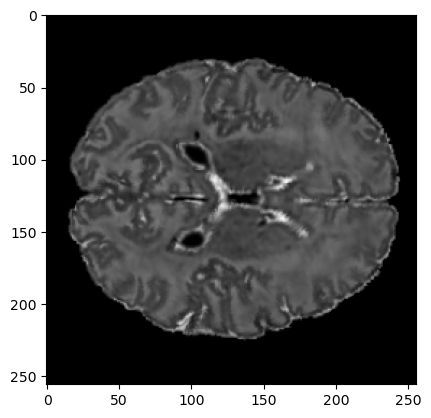

In [2]:
plt.imshow(sample_image.squeeze(),cmap='gray')
print("Age:",round(float(sample_label),2))

In [3]:
aug = Data_augmentation()

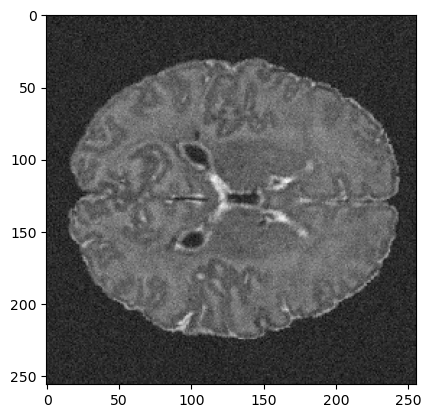

In [4]:
plt.imshow(aug.Gaussian_noise(sample_image.squeeze()),cmap='gray')

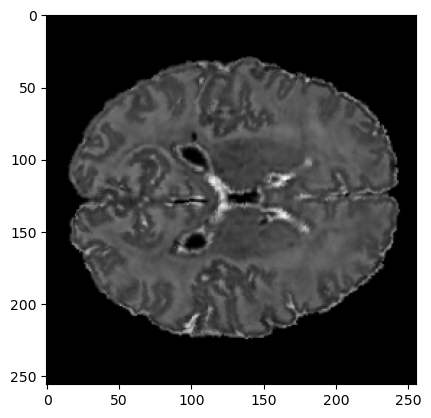

In [5]:
plt.imshow(aug.Rotation(sample_image.squeeze()),cmap='gray')

Rationale:
1) Gaussian Noise; I have added noise scaled to 5% of the image's maximum intensity to simulates realistic scan-to-scan variation in signal-to-noise ratio that would naturally arise across different scanners, field strengths, and acquisition parameters in a real clinical dataset. The probability of p = 0.4 using T.RandomApply means that the Gaussian noise is applied stochastically rather than deterministically (probability of 40% of being applied.
2) Rotation +-30 degrees Similar to what I did with the noise, I used T.RandomApply and assign p = 0.4 means the model sees both rotated and normal orientation during training. The remaining 20% of the dataset will be normal unaugmentated data.
- I expect the augmentation to result in reduction in overfitting which will be seen with a smaller gap between training and validation loss curves

### Regression Network: Predict Brain Age using an Encoder Model

I created a ResNet network to perform a supervised regression task. I used the mean absolute error (MAE) loss for regression to train my model for 200 epochs and performed validation every 10 epochs. I plotted the training and validation losses on the same plot to track performance over epochs. Initially I trained the model without augmentation and then I trained it with augmented data and compare performance.
I then tested this by feeding the model my test data and compare its prediction for each subject with the ground truth as well as calculating the average and standard deviation of the MAE of the test set for brain age prediction


## 2. Baseline Establishment: Brain Age Regression

Before tackling generative modeling, we first establish a baseline understanding of the dataset's features by training a supervised regression network.

[cite_start]Here, a ResNet-based encoder is implemented to predict the Gestational Age (GA) directly from the MRI slices[cite: 150, 151].
* [cite_start]**Objective:** The model is optimized using Mean Absolute Error (MAE) loss[cite: 151, 152].
* [cite_start]**Training Strategy:** The network is trained over 200 epochs, utilizing a Cosine Annealing learning rate scheduler[cite: 152, 218]. [cite_start]We compare the training dynamics between clean and augmented data to validate our augmentation strategy[cite: 154].
* [cite_start]**Evaluation:** Model performance is assessed on a held-out test set by comparing the predicted GA against the ground-truth GA, calculating the average MAE and standard deviation[cite: 155, 156].

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print ("device = ",device)

device =  cuda


In [7]:

class ResidualBlock(nn.Module):
    def __init__(self,channel1,channel2,res_stride = 1):
        super(ResidualBlock,self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(channel1,channel2,stride = res_stride,kernel_size = 3,padding = 1),
            nn.BatchNorm2d(channel2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(channel2,channel2,stride = 1,kernel_size = 3,padding = 1),
            nn.BatchNorm2d(channel2),
        )
        if res_stride !=1 or channel2 != channel1:
            self.skip = nn.Sequential(
                nn.Conv2d(channel1,channel2,stride = res_stride, kernel_size = 1,padding = 0),
                nn.BatchNorm2d(channel2)
            )

        else:
            self.skip = nn.Sequential()

    def forward(self,x):
        out = self.conv1(x)
        out = F.relu(out)
        out = self.conv2(out)
        out += self.skip(x)
        out = F.relu(out)
        return out


class ResnetEncoder(nn.Module):
    def __init__(self,blocks,num_blocks,strides,num_features,input_channels):
        super(ResnetEncoder,self).__init__()
        self.num_channel_output = num_features[0]
        self.initial_conv = nn.Sequential(
            nn.Conv2d(input_channels,num_features[0],kernel_size = 3,stride = strides[0],padding = 1),
            nn.BatchNorm2d(num_features[0]),
        )
        self.layer1 = self._make_layer(blocks,num_blocks,strides[1],num_features[1])
        self.layer2 = self._make_layer(blocks,num_blocks,strides[2],num_features[2])
        self.layer3 = self._make_layer(blocks,num_blocks,strides[3],num_features[3])
        self.layer4 = self._make_layer(blocks,num_blocks,strides[4],num_features[4])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1,1))
        self.final_layers = nn.Sequential(
            nn.Linear(num_features[4],128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128,1)
        )

    def _make_layer(self,blocks,num_blocks,strides,num_features):
        layers = []
        layers.append(blocks(self.num_channel_output, num_features, strides))
        self.num_channel_output = num_features
        for _ in range(num_blocks-1):
            layers.append(blocks(self.num_channel_output,num_features))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.initial_conv(x))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.adaptive_pool(out)
        out = out.view(out.size(0), -1)
        out = self.final_layers(out)
        return out

model= ResnetEncoder(ResidualBlock,2,strides=[1,1,2,2,2],num_features = [32,32,64,128,256],input_channels = 1)

Train Epoch: 5 Loss: 3.719869286925704  
Train Epoch: 10 Loss: 3.026703849671379  
Validation Epoch: 10 Loss: 2.2272770530299137  
Train Epoch: 15 Loss: 2.696488748782526  
Train Epoch: 20 Loss: 2.648573847674819  
Validation Epoch: 20 Loss: 2.827926477319316  
Train Epoch: 25 Loss: 2.431332797600479  
Train Epoch: 30 Loss: 2.271072566193878  
Validation Epoch: 30 Loss: 2.0615290262197195  
Train Epoch: 35 Loss: 1.9256411904380435  
Train Epoch: 40 Loss: 1.853279156659646  
Validation Epoch: 40 Loss: 1.8292896371138723  
Train Epoch: 45 Loss: 1.6813068743105288  
Train Epoch: 50 Loss: 1.560232949635339  
Validation Epoch: 50 Loss: 1.7775810988325822  
Train Epoch: 55 Loss: 1.4003160611662284  
Train Epoch: 60 Loss: 1.3513941808983132  
Validation Epoch: 60 Loss: 2.2667181993785657  
Train Epoch: 65 Loss: 1.193659991183609  
Train Epoch: 70 Loss: 1.112436574602884  
Validation Epoch: 70 Loss: 1.0339689129277279  
Train Epoch: 75 Loss: 1.0607435204995372  
Train Epoch: 80 Loss: 0.9804546

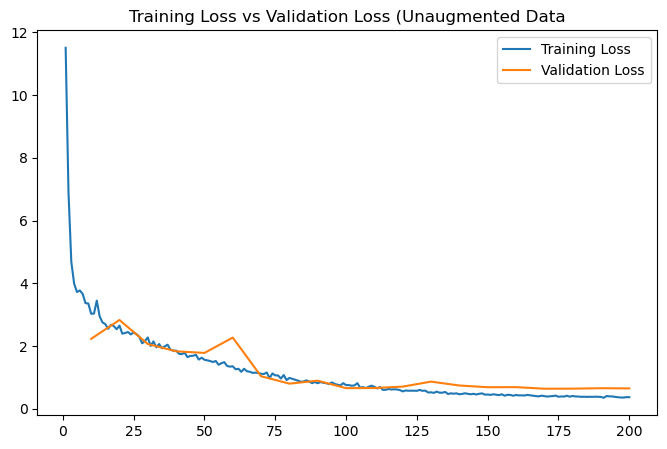

In [8]:
loss_function = nn.L1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01,momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = 200)
# TRAINING LOOP (without augmentation):
model = model.to(device)
def train(epoch,training_loss, log_interval = 5):
    model.train()
    epoch_loss = 0
    for i, (data,labels) in enumerate(train_loader_clean):
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_function(output.squeeze(),labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    average_training_loss = epoch_loss/len(train_loader_clean)
    training_loss.append(average_training_loss)
    if epoch % log_interval == 0:
        print("Train Epoch: {} Loss: {}  ".format(epoch,average_training_loss))

def validation(epoch,loss_amount):
    model.eval()
    validation_loss = 0
    with torch.no_grad():
        for i, (data,labels) in enumerate(val_loader):
            data, labels = data.to(device), labels.to(device)
            output = model(data)
            loss = loss_function(output.squeeze(),labels)
            validation_loss += loss.item()

        average_validation_loss = validation_loss/len(val_loader)
        loss_amount.append(average_validation_loss)
        print("Validation Epoch: {} Loss: {}  ".format(epoch,average_validation_loss))


# TRAIN YOUR MODEL TO ESTIMATE BRAIN AGE USING THE GROUND-TRUTH AGE LABELS FOR EACH IMAGE (USE MAE LOSS) ;
epoch_number = 200
training_loss = []
loss_amount = []
validation_run = 10
for epoch in range(1,epoch_number+1):
    train(epoch,training_loss)
    if epoch % validation_run == 0:
        validation(epoch,loss_amount)

# PLOT THE TRAIN AND VALIDATION LOSSES THROUGH THE EPOCHS

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(np.arange(1,epoch_number+1),training_loss,label = "Training Loss")
plt.plot(np.arange(10,epoch_number+1,10), loss_amount,label = "Validation Loss")
plt.title("Training Loss vs Validation Loss (Unaugmented Data")
plt.legend()

torch.save(model.state_dict(), "coursework_test_weights_hpccreate.pth")

Train Epoch: 5 Loss: 3.892790204002744  
Train Epoch: 10 Loss: 2.864666943827634  
Validation Epoch: 10 Loss: 2.1246391346580102  
Train Epoch: 15 Loss: 2.6894288870392655  
Train Epoch: 20 Loss: 2.6979576973688033  
Validation Epoch: 20 Loss: 2.0525675510105335  
Train Epoch: 25 Loss: 2.4716798994276257  
Train Epoch: 30 Loss: 2.254143929355359  
Validation Epoch: 30 Loss: 2.00511845475749  
Train Epoch: 35 Loss: 2.1064618201482865  
Train Epoch: 40 Loss: 1.798447086066796  
Validation Epoch: 40 Loss: 1.683793921219675  
Train Epoch: 45 Loss: 1.66971194554889  
Train Epoch: 50 Loss: 1.4648896291773155  
Validation Epoch: 50 Loss: 1.3177480572148372  
Train Epoch: 55 Loss: 1.403070636527248  
Train Epoch: 60 Loss: 1.2354983006204878  
Validation Epoch: 60 Loss: 1.1509517054808767  
Train Epoch: 65 Loss: 1.23355969676265  
Train Epoch: 70 Loss: 1.1899572437402433  
Validation Epoch: 70 Loss: 1.1594407432957698  
Train Epoch: 75 Loss: 1.0646882227488927  
Train Epoch: 80 Loss: 1.01254199

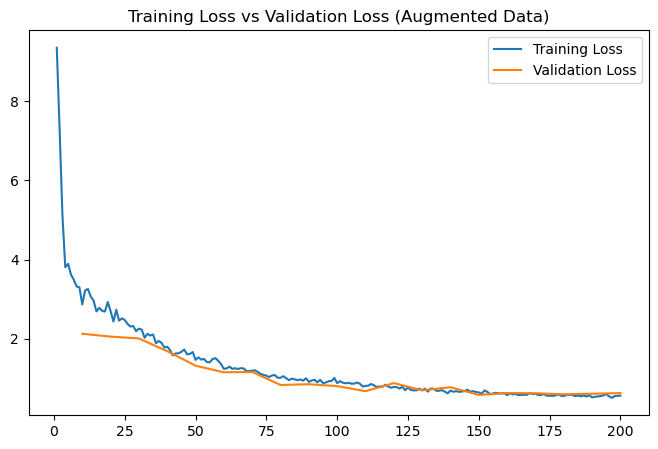

In [8]:
# TRAINING LOOP (with augmentation):
model_aug = ResnetEncoder(ResidualBlock,2,strides=[1,1,2,2,2],num_features = [32,32,64,128,256],input_channels = 1)
model_aug = model_aug.to(device)
loss_function = nn.L1Loss()
optimizer = torch.optim.SGD(model_aug.parameters(), lr = 0.01,momentum=0.9,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = 200)

def train(epoch,training_loss, log_interval = 5):
    model_aug.train()
    epoch_loss = 0
    for i, (data,labels) in enumerate(train_loader_aug):
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model_aug(data)
        loss = loss_function(output.squeeze(),labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    average_training_loss = epoch_loss/len(train_loader_aug)
    training_loss.append(average_training_loss)
    if epoch% log_interval ==0:
        print("Train Epoch: {} Loss: {}  ".format(epoch,average_training_loss))

def validation(epoch,loss_amount):
    model_aug.eval()
    validation_loss = 0
    with torch.no_grad():
        for i, (data,labels) in enumerate(val_loader):
            data, labels = data.to(device), labels.to(device)
            output = model_aug(data)
            loss = loss_function(output.squeeze(),labels)
            validation_loss += loss.item()

        average_validation_loss = validation_loss/len(val_loader)
        loss_amount.append(average_validation_loss)
        print("Validation Epoch: {} Loss: {}  ".format(epoch,average_validation_loss))

# TRAIN YOUR MODEL TO ESTIMATE BRAIN AGE USING THE GROUND-TRUTH AGE LABELS FOR EACH IMAGE (USE MAE LOSS) ;
epoch_number = 200
training_loss = []
loss_amount = []
validation_run = 10
for epoch in range(1,epoch_number+1):
    train(epoch,training_loss)
    if epoch % validation_run == 0:
        validation(epoch,loss_amount)

# plotting

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(np.arange(1,epoch_number+1),training_loss,label = "Training Loss")
plt.plot(np.arange(10,epoch_number+1,10), loss_amount,label = "Validation Loss")
plt.title("Training Loss vs Validation Loss (Augmented Data)")
plt.legend()


/scratch/users/k25136922/my-gpu-env/lib/python3.10/site-packages/torch/nn/modules/loss.py:101: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


average loss is:  0.46
standard deviation is:  0.17


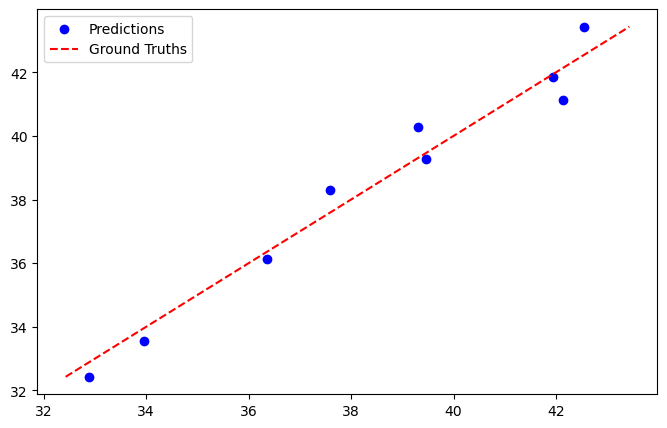

In [9]:
#testing the model
loss_function = nn.L1Loss()

model_aug.eval()
prediction = []
ground_truth = []
test_loss = 0
test_loss_sum = []
average_loss = 0
with torch.no_grad():
    for i, (data,labels) in enumerate(test_loader):
        data, labels = data.to(device), labels.to(device)
        output = model_aug(data)
        prediction.extend(output.flatten().tolist())
        ground_truth.extend(labels.tolist())
        loss = loss_function(output.squeeze(),labels)
        test_loss += loss.item()
        test_loss_sum.append(loss.item())
average_loss = np.sum(test_loss_sum)/len(test_loss_sum)
standard_deviation = np.std(test_loss_sum)

# DISPLAY INPUT IMAGES AND PREDICTED AGE VS. GROUND-TRUTH AGE FOR THE SUBJECTS IN YOUR TEST SET
plt.figure(figsize = (8,5))
plt.scatter(prediction,ground_truth,color = "blue",label = "Predictions")
min_age = min(ground_truth)
max_age = max(ground_truth)
plt.plot([min_age, max_age], [min_age, max_age], color="red", linestyle="--", label="Ground Truths")
plt.legend()
# CALCULATE AVERAGE AND STANDARD DEVIATION OF THE MAE OF YOUR TEST SET
print("average loss is: ",np.round(average_loss,2))
print("standard deviation is: ",np.round(standard_deviation,2))

### Variational Autoencoder (VAE)

the VAE's primary purpose is to transform input images into a latent representation that will later on be used by a latent diffusion model.

I implement a Complete ResNet VAE to handle this compression and subsequent reconstruction. Following the methodology outlined by Rombach et al.
- In the original paper (Rombach et al. (https://arxiv.org/abs/2112.10752)) the authors use a combination of a perceptual loss and a patch-based adversarial objective when training the VAE. In the model below, I trained the model using MSE, KL Divergence as well as perceptual loss via Monai. I train the model over 200 epochs and validate every 10 epochs.
- My patch-based discriminator model consists of 5 convolutional layers which is followed by a batchnorm and a leaky relu at each layer. A 5-layer convolutional Patch-based Discriminator is used to enforce high-frequency local realism and structural fidelity
- I tested the VAE by inference and evaluating the reconstructions as well as the mean and standard deviation of the reconstruction error






In [10]:
from monai.losses import PerceptualLoss
perceptual_loss_fun = PerceptualLoss(spatial_dims=2, network_type="radimagenet_resnet50").to(device)

/scratch/users/k25136922/my-gpu-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/users/k25136922/.cache/torch/hub/Warvito_radimagenet-models_main/radimagenet_models/models/resnet.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user vi

In [11]:
# defining my latent space block to be used in the complete encoder decoder type architecture
class LatentSpaceBlock(nn.Module):
    def __init__(self, feature_size,latent_channels):
        super(LatentSpaceBlock, self).__init__()
        self.logvars_upper_bound = 4
        self.logvars_lower_bound = -self.logvars_upper_bound
        self.logvar = nn.Conv2d(feature_size, latent_channels, kernel_size = 3, padding = 1)
        self.mu = nn.Conv2d(feature_size, latent_channels, kernel_size = 3, padding = 1)

    def forward(self, x):
        mu = self.mu(x)
        logvar = torch.clamp(
            self.logvar(x),
            self.logvars_lower_bound,
            self.logvars_upper_bound
        )
        if self.training:
            std = torch.exp(0.5*logvar)
            epsilon = torch.randn_like(std)
            z= mu + epsilon*std
        else:
            z = mu
        return z, mu, logvar

In [12]:
#my complete encoder decoder type architecture

class CompleteResNetVAE(nn.Module):
    def __init__(self, blocks=ResidualBlock, latent_channels=32):
        super(CompleteResNetVAE, self).__init__()

        strides = [1,1,2,2,2]
        num_features = [32, 32, 64, 128, 256]

        self.num_channel_output = num_features[0]

        self.initial_conv = nn.Sequential(
            nn.Conv2d(1, num_features[0], kernel_size=3, stride=strides[0], padding=1),
            nn.ReLU()
        )

        self.layer1 = self._make_layer(blocks, 2, strides[1], num_features[1])
        self.layer2 = self._make_layer(blocks, 2, strides[2], num_features[2])
        self.layer3 = self._make_layer(blocks, 2, strides[3], num_features[3])
        self.layer4 = self._make_layer(blocks, 2, strides[4], num_features[4])


        self.latent_space = LatentSpaceBlock(feature_size=256, latent_channels=latent_channels)


        self.initial_decoder = nn.Conv2d(latent_channels, 256, kernel_size=3, stride=1, padding=1)

        self.decoder1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        self.decoder2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
        )
        self.decoder3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

        self.age_predictor = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(latent_channels, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def _make_layer(self, blocks, num_blocks, stride, num_features):
        layers = []
        layers.append(blocks(self.num_channel_output, num_features, stride))
        self.num_channel_output = num_features
        for _ in range(num_blocks - 1):
            layers.append(blocks(self.num_channel_output, num_features))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.initial_conv(x)
        s1 = self.layer1(out)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        out = self.layer4(s3)

        z, mu, logvar = self.latent_space(out)
        age_predictor = self.age_predictor(mu)

        out = self.initial_decoder(z)

        out = self.decoder1(out)
        out = self.decoder2(out)
        out = self.decoder3(out)

        return age_predictor, out, mu, logvar

In [13]:
# my Patch discriminator model with 5 conv layers that is followed by batchnorm and leakyrelu then a final conv layer to map to 1 channel
class PatchDiscriminator (nn.Module):
    def __init__(self, input_channels,features = (32,32,64,128,256)):
        super(PatchDiscriminator,self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels, features[0], kernel_size = 3, stride = 2, padding = 1),
            nn.BatchNorm2d(features[0]),
            nn.LeakyReLU(0.2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(features[0], features[1], kernel_size = 3, stride = 2, padding = 1),
            nn.BatchNorm2d(features[1]),
            nn.LeakyReLU(0.2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(features[1], features[2], kernel_size = 3, stride = 2, padding = 1),
            nn.BatchNorm2d(features[2]),
            nn.LeakyReLU(0.2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(features[2], features[3], kernel_size = 3, stride = 2, padding = 1),
            nn.BatchNorm2d(features[3]),
            nn.LeakyReLU(0.2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(features[3], features[4], kernel_size = 3, stride = 2, padding = 1),
            nn.BatchNorm2d(features[4]),
            nn.LeakyReLU(0.2)
        )
        self.final_conv6 = nn.Conv2d(features[4], 1, kernel_size = 3, stride = 1, padding = 1)

    def forward(self,x):
        output = self.conv1(x)
        output = self.conv2(output)
        output = self.conv3(output)
        output = self.conv4(output)
        output = self.conv5(output)
        output = self.final_conv6(output)
        return output

Training Epoch: 1 Loss: 0.6472144661441682  
Training Epoch: 2 Loss: 0.3904054122311728  
Training Epoch: 3 Loss: 0.28785335930882305  
Training Epoch: 4 Loss: 0.22042499183031616  
Training Epoch: 5 Loss: 0.18253131443388249  
Training Epoch: 6 Loss: 0.16291610999082132  
Training Epoch: 7 Loss: 0.13658003059644547  
Training Epoch: 8 Loss: 0.1330751915063177  
Training Epoch: 9 Loss: 0.12161887054720884  
Training Epoch: 10 Loss: 0.11353046841249265  
Validation Epoch: 10 Loss: 0.08101509080121391  
Training Epoch: 11 Loss: 0.1141888826454758  
Training Epoch: 12 Loss: 0.1073481109407213  
Training Epoch: 13 Loss: 0.10558744374091032  
Training Epoch: 14 Loss: 0.10325583622411445  
Training Epoch: 15 Loss: 0.10470446321383986  
Training Epoch: 16 Loss: 0.10385693672788206  
Training Epoch: 17 Loss: 0.10058298990840003  
Training Epoch: 18 Loss: 0.10086531333980106  
Training Epoch: 19 Loss: 0.10219420141801633  
Training Epoch: 20 Loss: 0.09565286066323991  
Validation Epoch: 20 Loss

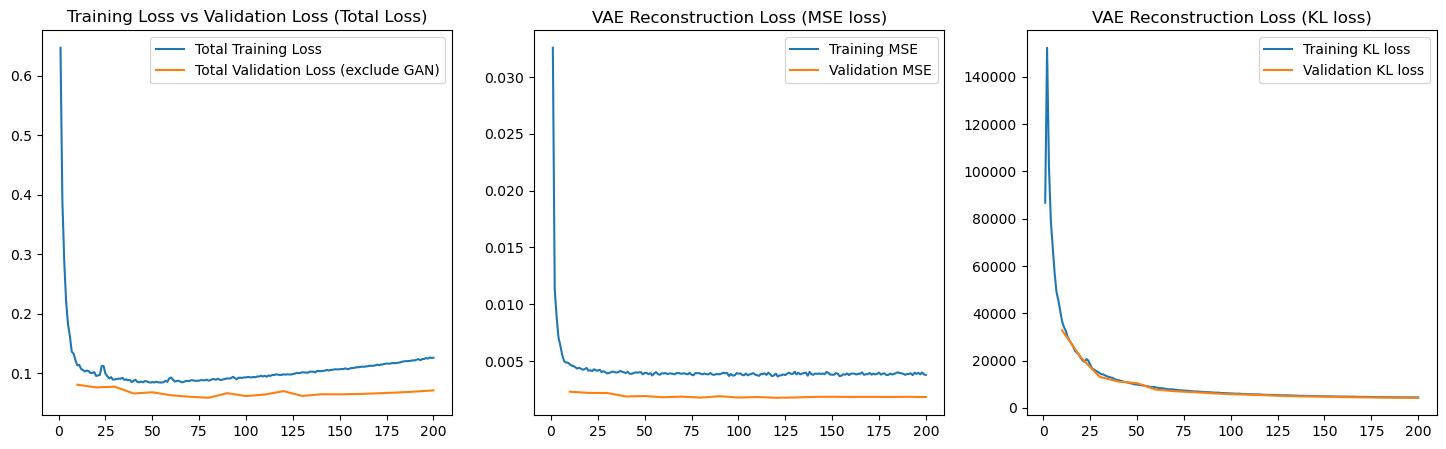

In [15]:
# training my model setting the optimizer to Adam and scheduler to CosineAnnealingLR

patch_discriminator_model = PatchDiscriminator(1).to(device)
VAEmodel = CompleteResNetVAE().to(device)
optimizer_discriminator = torch.optim.Adam(patch_discriminator_model.parameters(), lr=0.0002)
scheduler_discriminator = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_discriminator, T_max = 200)
optimizer_vae = torch.optim.Adam(VAEmodel.parameters(), lr=0.0002)
scheduler_vae = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vae, T_max = 200)

# I also decided to separate epoch_loss, epoch_kl and epoch_mse so that later I can display them in different plots
def train_network(epoch,training_loader,training_loss,kl_weight,gan_weight):
    VAEmodel.train()
    patch_discriminator_model.train()
    epoch_loss = 0
    epoch_kl = 0
    epoch_mse = 0
    for i, (data,label) in enumerate(training_loader):
      data, label = data.to(device), label.to(device)

#predict first
      age_prediction,output, code_mu, code_logvar = VAEmodel(data)

#patch discriminator block
      optimizer_discriminator.zero_grad()
      real_prediction = patch_discriminator_model(data)
      target_real = torch.ones_like(real_prediction).to(device)
      diff_real = F.mse_loss(real_prediction,target_real)

      fake_prediction = patch_discriminator_model(output.detach())
      target_fake = torch.zeros_like(fake_prediction).to(device)
      diff_fake = F.mse_loss(fake_prediction,target_fake)

      diff_loss = (diff_real+diff_fake)*0.5
      diff_loss.backward()
      optimizer_discriminator.step()

#VAE block

      optimizer_vae.zero_grad()
      kl_divergence = -0.5 * torch.sum(1 + code_logvar - code_mu.pow(2) - code_logvar.exp(), dim=[1, 2, 3])
      kl_loss = torch.mean(kl_divergence)
      mse_loss = F.mse_loss(output,data)
      epoch_mse += mse_loss.item()
      epoch_kl += kl_loss.item()
      age_loss = F.l1_loss(age_prediction.squeeze(),label)

      p_loss = perceptual_loss_fun(output,data).mean()

#passing the output to the model again with goal to make the output close to 1.0
      model_prediction = patch_discriminator_model(output)
      gan_loss = F.mse_loss(model_prediction,target_real)
      total_loss = mse_loss + (kl_weight * kl_loss) + (gan_weight*gan_loss) + (0.5*p_loss) + (0.001*age_loss)
      epoch_loss += total_loss.item()
      total_loss.backward()
      optimizer_vae.step()
    scheduler_vae.step()
    scheduler_discriminator.step()
    average_training_loss = epoch_loss / len(training_loader)
    training_mse.append(epoch_mse/len(training_loader))
    training_kl.append(epoch_kl/len(training_loader))
    training_loss.append(average_training_loss)
    print("Training Epoch: {} Loss: {}  ".format(epoch,average_training_loss))

def validation(epoch,validation_loader,validation_loss,kl_weight):
    VAEmodel.eval()
    epoch_loss = 0
    epoch_mse = 0
    epoch_kl = 0
    with torch.no_grad():
        for i, (data,labels) in enumerate(validation_loader):
            data, labels = data.to(device), labels.to(device)
            age_prediction,output, code_mu, code_logvar = VAEmodel(data)
            kl_divergence = -0.5 * torch.sum(1 + code_logvar - code_mu.pow(2) - code_logvar.exp(), dim=[1, 2, 3])
            mse_loss = F.mse_loss(output,data)
            kl_loss = torch.mean(kl_divergence)
            epoch_mse += mse_loss.item()
            epoch_kl += kl_loss.item()
            age_loss = F.l1_loss(age_prediction.squeeze(),labels)
            p_loss = perceptual_loss_fun(output,data).mean()
            total_loss = mse_loss + (kl_weight * kl_loss) + (0.5*p_loss) + (0.001*age_loss)
            epoch_loss += total_loss.item()

        validation_mse.append(epoch_mse/len(validation_loader))
        validation_kl.append(epoch_kl/len(validation_loader))
        average_validation_loss = epoch_loss/len(validation_loader)

        validation_loss.append(average_validation_loss)
        print("Validation Epoch: {} Loss: {}  ".format(epoch,average_validation_loss))


training_mse = []
validation_mse = []
training_kl = []
validation_kl = []

epoch_number = 200
training_loss = []
validation_loss = []
validation_run = 10
for epoch in range(1,epoch_number+1):
    kl_weight = min(0.00001, (epoch / epoch_number) * 0.00001)
    gan_weight = 0.05 * max(0, (epoch - 50) / epoch_number)
    train_network(epoch,train_loader_aug,training_loss,kl_weight,gan_weight)
    if epoch % validation_run == 0:
        validation(epoch,val_loader,validation_loss,kl_weight)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(np.arange(1,epoch_number+1),training_loss,label = "Total Training Loss")
axes[0].plot(np.arange(10,epoch_number+1,10), validation_loss,label = "Total Validation Loss (exclude GAN)")
axes[0].set_title("Training Loss vs Validation Loss (Total Loss)")
axes[0].legend()

axes[1].plot(np.arange(1, epoch_number+1), training_mse, label="Training MSE")
axes[1].plot(np.arange(10, epoch_number+1, 10), validation_mse, label="Validation MSE")
axes[1].set_title("VAE Reconstruction Loss (MSE loss)")
axes[1].legend()

axes[2].plot(np.arange(1, epoch_number+1), training_kl, label="Training KL loss")
axes[2].plot(np.arange(10, epoch_number+1, 10), validation_kl, label="Validation KL loss")
axes[2].set_title("VAE Reconstruction Loss (KL loss)")
axes[2].legend()

In [16]:
save_path = "/scratch/users/k25136922/coursework_test_weights_VAEmodel_hpccreate_new.pth"
torch.save(VAEmodel.state_dict(), save_path)

<Figure size 640x480 with 0 Axes>

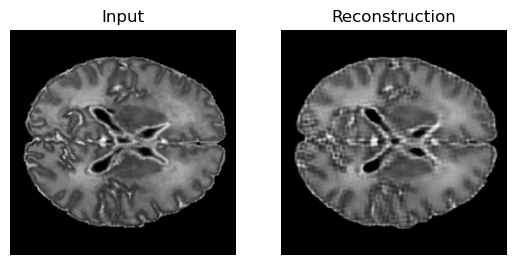

<Figure size 640x480 with 0 Axes>

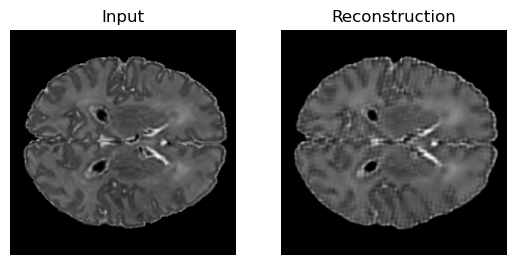

<Figure size 640x480 with 0 Axes>

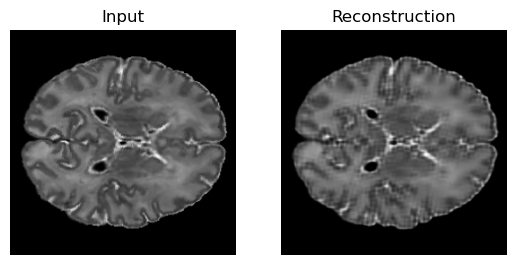

Test Loss: 0.0021630777046084404
Standard Deviation: 6.245665544458523e-05


In [17]:
#testing my model with input vs reconstruction image

totalmseloss = []
beta  = 0.1
input_list_fordisplay = []
output_list_fordisplay = []
VAEmodel.eval()
with torch.no_grad():
    for i, (data,labels) in enumerate(test_loader):
        data, labels = data.to(device), labels.to(device)
        data = F.interpolate(data, size=(256, 256), mode='bilinear', align_corners=False)
        age_prediction,output, code_mu, code_logvar = VAEmodel(data)
        if len(output_list_fordisplay) < 3:
            input_list_fordisplay.append(data)
            output_list_fordisplay.append(output)
        kl_divergence = -0.5 * torch.sum(1 + code_logvar - code_mu.pow(2) - code_logvar.exp(), dim=[1, 2, 3])
        totalmseloss.append(F.mse_loss(output,data).item())

#my display function to directly compare input image with reconstuction image
def display_input_reconstruct(input, reconstruction):
    plt.figure()
    f, axarr = plt.subplots(1, 2)

    axarr[0].imshow(input.squeeze().cpu(), cmap="gray")
    axarr[0].axis('off')
    axarr[0].title.set_text("Input")

    axarr[1].imshow(reconstruction.squeeze().cpu(), cmap="gray")
    axarr[1].axis('off')
    axarr[1].title.set_text("Reconstruction")

    plt.show()

for i in range(3):
    display_input_reconstruct(input_list_fordisplay[i][0],output_list_fordisplay[i][0])


# calcuate and print the average and standard deviation of the MSE loss
average_test_loss = np.sum(totalmseloss) / len(totalmseloss)
print("Test Loss: {}".format(average_test_loss))
standard_deviation_test = np.std(totalmseloss)
print("Standard Deviation: {}".format(standard_deviation_test))


### Age-Conditioned Latent Diffusion Model

Now I define a Latent Diffusion Model (LDM), the core of the LDM is a Conditional U-Net featuring residual blocks, group normalization, and attention mechanisms

I utilised a Denoising Diffusion Probabilistic Model (DDPM) scheduler to systematically add and remove noise.

Instead of generating random brain slices, the U-Net is conditioned on a specific Gestational Age scalar. This allows me to explicitly control the generative process, synthesizing brains that structurally represent a specific developmental week.

Timestep Encoding: The current diffusion step t is projected into a dense vector space using Sinusoidal Embeddings, providing the model with a temporal awareness of the noise scale.

Age Encoding: The target Gestational Age is normalized against the maximum dataset age (40 weeks) and passed through a dedicated MLP (Linear → ReLU → Linear). This maps the scalar condition into a high-dimensional latent vector that matches the embedding dimension of the current U-Net layer.

Conditioning Injection: Rather than using cross-attention for this simple scalar condition, I added the spatial age embedding directly to the sinusoidal time embedding (t emb +age emb). This fused state vector is injected into every ResBlock in the U-Net via addition. This allows the network to continuously shift its feature maps based on both the noise level and the target developmental age.

I performed validation at every 10 epoch and also ran inference at every 10 epochs to demonstrate the performance of the model



In [18]:

#first i define the time embedding
class SinusoidalEmbeddings(nn.Module):
    def __init__(self, time_steps, embed_dim):
        super().__init__()

        position = torch.arange(time_steps).unsqueeze(1).float()

        div = torch.exp(torch.arange(0, embed_dim, 2).float() * -(math.log(10000.0) / embed_dim))
        embeddings = torch.zeros(time_steps, embed_dim, requires_grad=False)
        embeddings[:, 0::2] = torch.sin(position * div) # generating the sin components
        embeddings[:, 1::2] = torch.cos(position * div)  # generating the cosine components
        self.register_buffer('embeddings', embeddings)

    def forward(self, x, t):
        embeds = self.embeddings[t].to(x.device)
        return embeds[:, :, None, None]


# Next I define the residual block which contains relu, group norm and conv with dropout set to 0.1
class ResBlock(nn.Module):
    def __init__(self, channels, num_groups=32, dropout_prob=0.1):
        super(ResBlock,self).__init__()
        self.relu = nn.ReLU(inplace=True)
        self.gnorm1 = nn.GroupNorm(num_groups=num_groups, num_channels=channels)
        self.gnorm2 = nn.GroupNorm(num_groups=num_groups, num_channels=channels)
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=dropout_prob, inplace=True)

    def forward(self, x, embeddings):

        # I reshaped the embedding to match the latents and then add to input
        emb=embeddings[:, :x.shape[1], :, :]
        x = x + emb
        # for resnet each has two conv layers, with relu activations and group norm separated by dropout
        r = self.conv1(self.relu(self.gnorm1(x)))
        r = self.dropout(r)
        r = self.conv2(self.relu(self.gnorm2(r)))
        # then I add the skip connection to the output r
        return r + x


class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads = 8, dropout_prob = 0.1):
        super(AttentionBlock,self).__init__()
        self.proj1 = nn.Linear(channels, channels*3)
        self.proj2 = nn.Linear(channels, channels)
        self.num_heads = num_heads
        self.head_dim = channels // num_heads
        self.dropout_prob = dropout_prob
        self.channels=channels

    def forward(self, x):
        b, c, h, w = x.shape
        x = x.view(b, c, h * w).permute(0, 2, 1)
        x = self.proj1(x)
        x = x.view(b, h * w, 3, self.num_heads, self.head_dim)
        x = x.permute(2, 0, 3, 1, 4)
        q,k,v = x[0], x[1], x[2]
        x = F.scaled_dot_product_attention(q,k,v, is_causal=False, dropout_p=self.dropout_prob)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(b, h, w, c)
        # Final projection and return to (b, c, h, w)
        x = self.proj2(x)
        return x.permute(0, 3, 1, 2).contiguous()


#my Diffusionnetwork with attention
class DiffusionUNet(nn.Module):
    def __init__(self, num_time_steps=1000, in_ch=4, channels=[64,128,256,512,512,384]):
        super(DiffusionUNet,self).__init__()

        self.init_conv = nn.Conv2d(in_ch, channels[0], 3, padding=1)

        self.res1a = ResBlock(channels[0])
        self.res1b = ResBlock(channels[0])
        self.down1 = nn.Conv2d(channels[0], channels[1], 3, stride=2, padding=1) # -> 32x32

        self.res2a = ResBlock(channels[1])
        self.res2b = ResBlock(channels[1])
        self.down2 = nn.Conv2d(channels[1], channels[2], 3, stride=2, padding=1) # -> 16x16

        self.res3a = ResBlock(channels[2])
        self.res3b = ResBlock(channels[2])
        self.attn3 = AttentionBlock(channels[2])
        self.down3 = nn.Conv2d(channels[2], channels[3], 3, stride=2, padding=1) # -> 8x8

        self.mid1 = ResBlock(channels[3])
        self.mid2 = ResBlock(channels[3])

        self.up3 = nn.ConvTranspose2d(channels[3], channels[3]//2, 4, stride=2, padding=1)
        self.resD3a = ResBlock(channels[4])
        self.resD3b = ResBlock(channels[4])

        self.u_attn3 = AttentionBlock(channels[4])

        self.up2 = nn.ConvTranspose2d(channels[4],channels[4]//2, 4, stride=2, padding=1)
        self.resD2a = ResBlock(channels[5]) #channels[5] is equal to channels[4]+channels[1] due to skip connection
        self.resD2b = ResBlock(channels[5])

        self.up1 = nn.ConvTranspose2d(channels[5], channels[5]//2, 4, stride=2, padding=1)
        self.final_conv1 = nn.Conv2d(channels[5]//2+channels[0], channels[0], 3, padding=1)

        self.final_conv2 = nn.Conv2d(64, in_ch, 1)

        self.embeddings = SinusoidalEmbeddings(time_steps=num_time_steps, embed_dim=max(channels))

        self.age_mlp = nn.Sequential(
            nn.Linear(1, max(channels)),
            nn.ReLU(),
            nn.Linear(max(channels), max(channels))
)

    def forward(self, x,t,age):
        t_emb = self.embeddings(x, t)
        age_emb = self.age_mlp(age.unsqueeze(1))[:, :, None, None]
        t_emb = t_emb + age_emb

        # This is the encoder
        x = self.init_conv(x)

        x = self.res1a(x, t_emb)
        s1 = self.res1b(x, t_emb)            # Skip 1 (64x64)

        x = self.down1(s1)
        x = self.res2a(x, t_emb)
        s2 = self.res2b(x, t_emb)          # Skip 2 (32x32)

        x = self.down2(s2)
        x = self.res3a(x, t_emb)
        x = self.attn3(x)
        s3 = self.res3b(x, t_emb)          # Skip 3 (16x16)


        # This is the bottleneck
        x = self.down3(s3)
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        # And this is the decoder
        x = self.up3(x)
        x = torch.cat([x, s3], dim=1) # Concat Skip 3
        x = self.resD3a(x, t_emb)
        x = self.resD3b(x, t_emb)
        x = self.u_attn3(x)

        x = self.up2(x)
        x = torch.cat([x, s2], dim=1) # Concat Skip 2
        x = self.resD2a(x, t_emb)
        x = self.resD2b(x, t_emb)

        x = self.up1(x)
        x = torch.cat([x, s1], dim=1) # Concat Skip 1
        x=self.final_conv1(x)
        return self.final_conv2(x)




In [19]:
import math
diffusion_model = DiffusionUNet(in_ch = 32).to(device)
# 1. Create the generator and tie it to a device to ensure reproducibility
gen = torch.Generator(device=device).manual_seed(42)

#get the scale factor
VAEmodel.eval()

# initialise random noise for diffusion
initial_noise = torch.randn((1, 32, 32, 32), generator=gen, device=device)

mu std: 0.3398
decoded range: 0.0000 to 0.9449


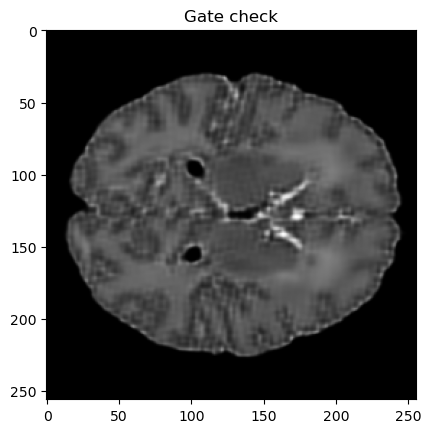

In [20]:
VAEmodel.eval()
with torch.no_grad():
    data, _ = next(iter(val_loader))
    _, _, mu, _ = VAEmodel(data.to(device))
    test = VAEmodel.decoder3(VAEmodel.decoder2(
           VAEmodel.decoder1(VAEmodel.initial_decoder(mu))))

print(f"mu std: {mu.std().item():.4f}")
print(f"decoded range: {test.min().item():.4f} to {test.max().item():.4f}")
plt.imshow(test[0,0].cpu(), cmap='gray')
plt.title('Gate check')
plt.show()

Latent Mean: -0.0221
Latent Std: 0.3431
Train Epoch: 5 Loss: 0.3637028872651398  
Train Epoch: 10 Loss: 0.25296820195579023  
Validation Epoch: 10 Loss: 0.21165145933628082  
Running inference: 


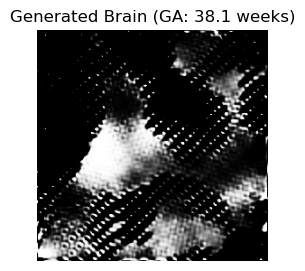

Train Epoch: 15 Loss: 0.2357650083839578  
Train Epoch: 20 Loss: 0.21423491122072966  
Validation Epoch: 20 Loss: 0.16503645048329704  
Running inference: 


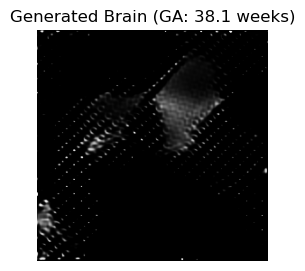

Train Epoch: 25 Loss: 0.18856607186336996  
Train Epoch: 30 Loss: 0.17303258476276245  
Validation Epoch: 30 Loss: 0.17963824656448865  
Running inference: 


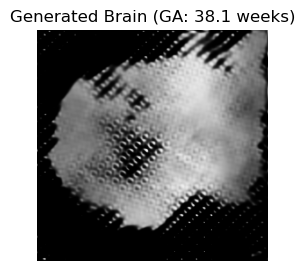

Train Epoch: 35 Loss: 0.17225224911062806  
Train Epoch: 40 Loss: 0.1617034823490829  
Validation Epoch: 40 Loss: 0.15227635989063665  
Running inference: 


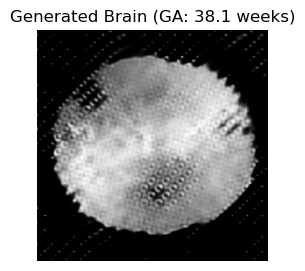

Train Epoch: 45 Loss: 0.16025649277227266  
Train Epoch: 50 Loss: 0.15589493776242885  
Validation Epoch: 50 Loss: 0.13030690758636124  
Running inference: 


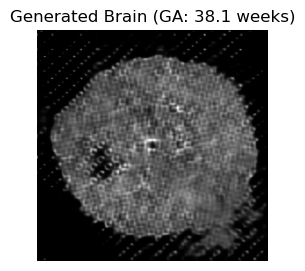

Train Epoch: 55 Loss: 0.14530119562038668  
Train Epoch: 60 Loss: 0.13731311698242155  
Validation Epoch: 60 Loss: 0.11029298760389027  
Running inference: 


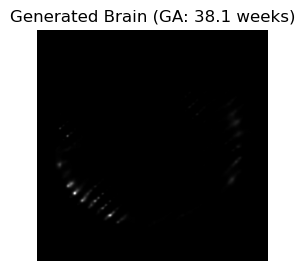

Train Epoch: 65 Loss: 0.14756104003184686  
Train Epoch: 70 Loss: 0.14549626820972042  
Validation Epoch: 70 Loss: 0.08229136520898656  
Running inference: 


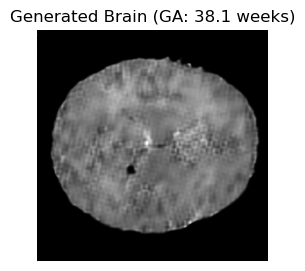

Train Epoch: 75 Loss: 0.1338813544581176  
Train Epoch: 80 Loss: 0.13188083756163163  
Validation Epoch: 80 Loss: 0.0912956813056218  
Running inference: 


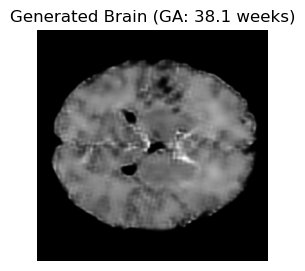

Train Epoch: 85 Loss: 0.1214817553640358  
Train Epoch: 90 Loss: 0.11930945319512849  
Validation Epoch: 90 Loss: 0.0885528962765085  
Running inference: 


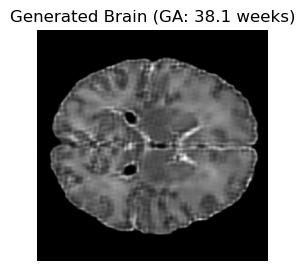

Train Epoch: 95 Loss: 0.11160745817635741  
Train Epoch: 100 Loss: 0.11499821385319428  
Validation Epoch: 100 Loss: 0.10921009179008634  
Running inference: 


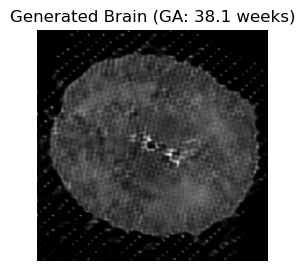

Train Epoch: 105 Loss: 0.11443397012987623  
Train Epoch: 110 Loss: 0.12117448333828222  
Validation Epoch: 110 Loss: 0.10665924175593414  
Running inference: 


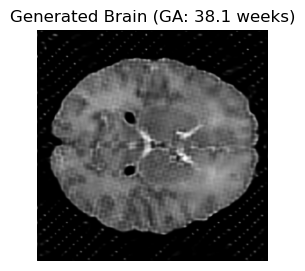

Train Epoch: 115 Loss: 0.10551713282370535  
Train Epoch: 120 Loss: 0.11742203371973817  
Validation Epoch: 120 Loss: 0.10651905025894705  
Running inference: 


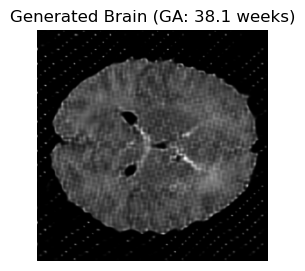

Train Epoch: 125 Loss: 0.11322996486963892  
Train Epoch: 130 Loss: 0.12510011899506762  
Validation Epoch: 130 Loss: 0.10576057066454699  
Running inference: 


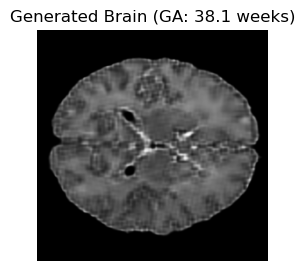

Train Epoch: 135 Loss: 0.1113902318399774  
Train Epoch: 140 Loss: 0.11066960871081662  
Validation Epoch: 140 Loss: 0.11459431414933581  
Running inference: 


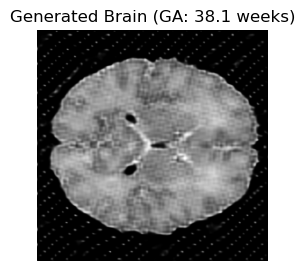

Train Epoch: 145 Loss: 0.1192581351531088  
Train Epoch: 150 Loss: 0.11560055011361049  
Validation Epoch: 150 Loss: 0.11284375190734863  
Running inference: 


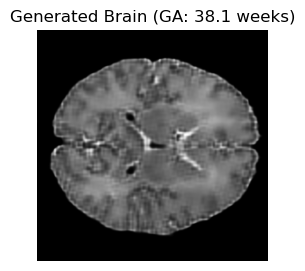

Train Epoch: 155 Loss: 0.12184252917874978  
Train Epoch: 160 Loss: 0.09575320456039023  
Validation Epoch: 160 Loss: 0.12135904772501242  
Running inference: 


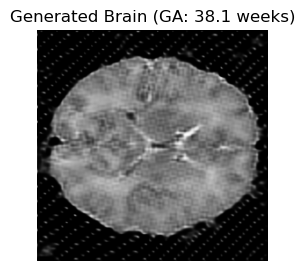

Train Epoch: 165 Loss: 0.10649057976389058  
Train Epoch: 170 Loss: 0.0978436856407416  
Validation Epoch: 170 Loss: 0.07306344978707402  
Running inference: 


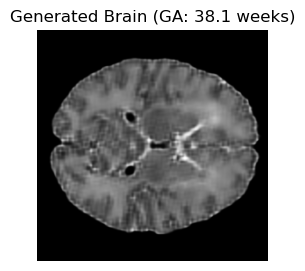

Train Epoch: 175 Loss: 0.10813458989467964  
Train Epoch: 180 Loss: 0.11031806425600456  
Validation Epoch: 180 Loss: 0.09013960000715758  
Running inference: 


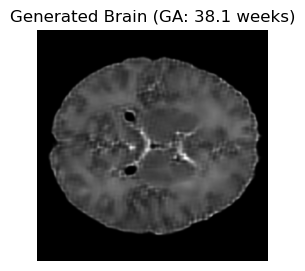

Train Epoch: 185 Loss: 0.10772261474153431  
Train Epoch: 190 Loss: 0.12358418664348031  
Validation Epoch: 190 Loss: 0.0970290037558267  
Running inference: 


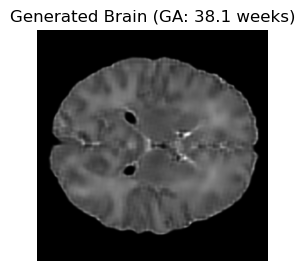

Train Epoch: 195 Loss: 0.11340715955676776  
Train Epoch: 200 Loss: 0.09871457565437865  
Validation Epoch: 200 Loss: 0.10663942899554968  
Running inference: 


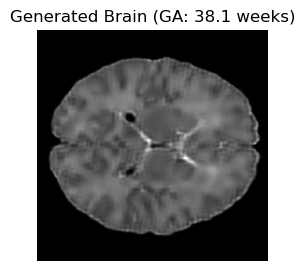

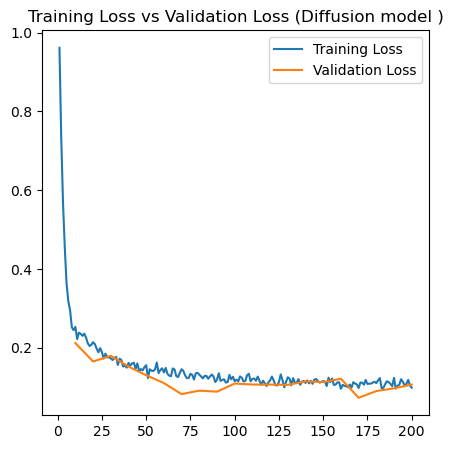

In [21]:
# train my conditional LDM

from timm.utils import ModelEmaV3

#this is the noise scheduler which determines the amount of noise to add to the image
class DDPM_Scheduler(nn.Module):
    def __init__(self, num_time_steps: int=1000):
        super().__init__()
        self.beta = torch.linspace(1e-4, 0.02, num_time_steps, requires_grad=False)
        alpha = 1 - self.beta
        self.alpha = torch.cumprod(alpha, dim=0).requires_grad_(False)

    def forward(self, t):
        return self.beta[t], self.alpha[t]

def add_noise(x, num_time_steps, scheduler):
    t = torch.randint(0,num_time_steps,(x.shape[0],))
    e = torch.randn_like(x)
    a = scheduler.alpha[t].view(x.shape[0],1,1,1).to(device)
    x = (torch.sqrt(a)*x) + (torch.sqrt(1-a)*e)
    return x,t,e

def train(diffusion_model, moving_average,latent_mean,latent_std,num_time_steps=1000,num_epochs=200,lr=2e-5,log_interval = 5):

    optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=lr)
    DDPM = DDPM_Scheduler(num_time_steps=num_time_steps).to(device)
    criterion = nn.MSELoss(reduction='mean')


    # Train the network
    for epoch in range(1, num_epochs+1):
        epoch_loss = 0
        for i,(data,labels) in enumerate(train_loader_aug):
            diffusion_model.train()
            # Move input to device
            data,labels = data.to(device, dtype=torch.float), labels.to(device, dtype=torch.float)
            labels = labels/40.0

            optimizer.zero_grad()
            with torch.no_grad():
                age_prediction,output, mu, logvar = VAEmodel(data)
            mu = (mu - latent_mean) / latent_std
            x,t,e=add_noise(mu,num_time_steps,DDPM)
            pred=diffusion_model(x,t,labels)
            loss = criterion(pred, e)
            # Back-propagation of gradients
            loss.backward()
            epoch_loss += loss.item()
            optimizer.step()
        average_training_loss = epoch_loss / len(train_loader_aug)
        training_loss.append(average_training_loss)
        if epoch % log_interval == 0:
            print("Train Epoch: {} Loss: {}  ".format(epoch,average_training_loss))

        # update ema
        moving_average.update(diffusion_model)

#run validation and inference every 10 epochs
        if epoch % 10 == 0:
            diffusion_model.eval()
            val_loss=0
#first run validation
            with torch.no_grad():
                for i, (data,labels) in enumerate(val_loader):
                    data,labels = data.to(device, dtype=torch.float),labels.to(device, dtype=torch.float)
                    labels = labels/40.0
                  # TO do generate noisy input from scheduler
                    age_prediction, output, mu, logvar = VAEmodel(data)
                    mu = (mu - latent_mean) / latent_std
                    x,t,e=add_noise(mu,num_time_steps,DDPM)
                  # TO do predict denoised output
                    pred=diffusion_model(x,t,labels)
                  # TO do calculate and acccumulate the loss
                    val_loss += criterion(pred, e).item()
                average_validation_loss = val_loss/len(val_loader)
                validation_loss_total.append(average_validation_loss)
                print("Validation Epoch: {} Loss: {}  ".format(epoch,average_validation_loss))
#running inference
            print("Running inference: ")
            sample_data, sample_ages = next(iter(val_loader))
            target_age = sample_ages[0].item()  # use a real GA from validation

            # Generate the image
            generated_img = generate_brain_image(
                diffusion_model=diffusion_model, # Use the EMA model for better results!
                VAEmodel=VAEmodel,
                scheduler=DDPM,
                age_label=target_age,
                latent_mean=latent_mean,
                latent_std=latent_std,
                latent_shape=(1, 32, 32, 32),
                # This safely borrows the exact shape from your forward pass
                num_time_steps=num_time_steps,
                device=device
            )
            plt.figure(figsize=(3,3))
            plt.imshow(generated_img[0,0].cpu().numpy(), cmap='gray')
            plt.title(f"Generated Brain (GA: {target_age :.1f} weeks)")
            plt.axis('off')
            plt.show()


#Generates a new brain image by reverse-diffusing random noise in the latent space, conditioned on a specific age.
@torch.no_grad()
def generate_brain_image(diffusion_model, VAEmodel, scheduler, age_label,latent_mean,latent_std,latent_shape=(1, 32, 32, 32), num_time_steps=1000, device='cuda'):

    diffusion_model.eval()
    VAEmodel.eval()

    # I start with pure random noise in the latent space
    x = torch.randn(latent_shape, device=device)

    # I need to format the age condition to match what Unet expects
    age_tensor = torch.tensor([age_label/40.0], device=device, dtype=torch.float)

    # I then loop backwards from T-1 down to 0, predict the noise and calculate the denoised mean
    for i in reversed(range(num_time_steps)):
        t = torch.full((1,), i, device=device, dtype=torch.long)

        predicted_noise = diffusion_model(x, t, age_tensor)
        alpha_t = 1.0 - scheduler.beta[i].to(device)
        alpha_bar_t = scheduler.alpha[i].to(device)

        mean = (1.0 / torch.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * predicted_noise)

        # If not at the final step, I add a small amount of random noise back in
        if i > 0:
            noise = torch.randn_like(x)
            sigma = torch.sqrt(scheduler.beta[i].to(device))
            x = mean + sigma * noise
        else:
            # At step 0 I don't add extra noise and output mean
            x = mean

    x = (x * latent_std) + latent_mean

    generated_image = VAEmodel.decoder3(VAEmodel.decoder2(VAEmodel.decoder1((VAEmodel.initial_decoder(x)))))
    return generated_image


diffusion_model = DiffusionUNet(in_ch=32).to(device)
ema = ModelEmaV3(diffusion_model, decay=0.995)

VAEmodel.eval()
with torch.no_grad():
    all_mu = []
    for data, _ in train_loader_clean:
        _, _, mu, _ = VAEmodel(data.to(device))
        all_mu.append(mu)
    all_mu = torch.cat(all_mu, dim=0)

latent_mean = all_mu.mean().item()
latent_std = all_mu.std().item()

print(f"Latent Mean: {latent_mean:.4f}")
print(f"Latent Std: {latent_std:.4f}")


training_loss=[]
validation_loss_total=[]
num_epochs = 200
VAEmodel.eval()
for param in VAEmodel.parameters():
    param.requires_grad = False

train(diffusion_model,ema,latent_mean,latent_std,num_time_steps=1000,num_epochs=200,lr=1e-4)

# here I plotted the training loss vs validation loss for my diffusion model through the epochs
import matplotlib.pyplot as plt


plt.figure(figsize = (5,5))
plt.plot(np.arange(1,num_epochs+1),training_loss,label = "Training Loss")
plt.plot(np.arange(10,num_epochs+1,10),validation_loss_total,label = "Validation Loss")
plt.title("Training Loss vs Validation Loss (Diffusion model )")
plt.legend()


In [22]:
save_path_diffusion = "/scratch/users/k25136922/coursework_test_weights_diffusion_hpccreate_new.pth"
torch.save(diffusion_model.state_dict(), save_path_diffusion)

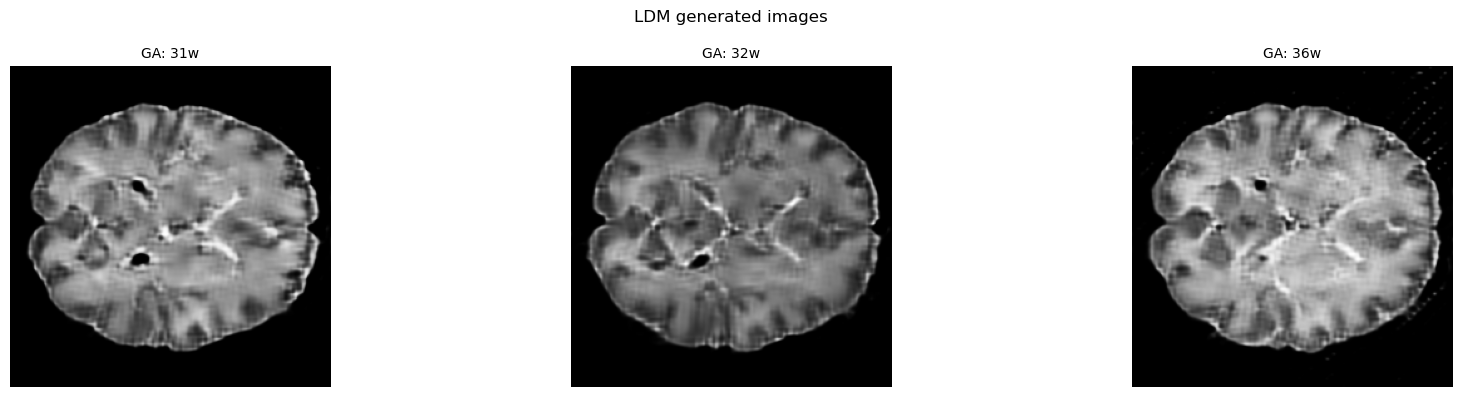

In [23]:
# Here I selected age samples to generate to test the model
VAEmodel.eval()
ages_to_generate = [31.2,32,35.9]
fig, axes = plt.subplots(1, len(ages_to_generate), figsize=(18, 4))

for idx, target_age in enumerate(ages_to_generate):


    generated_img = generate_brain_image(
        diffusion_model=diffusion_model,
        VAEmodel=VAEmodel,
        scheduler=DDPM_Scheduler(num_time_steps=1000).to(device),
        age_label=float(target_age)/40,
        latent_mean = latent_mean,
        latent_std = latent_std,
        latent_shape=(1, 32, 32, 32),
        num_time_steps=1000,
        device=device
    )
    axes[idx].imshow(generated_img[0, 0].cpu().numpy(), cmap='gray')
    axes[idx].set_title(f'GA: {target_age:.0f}w', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('LDM generated images', fontsize=12)
plt.tight_layout()
plt.show()


### Comparison**

Finally, since the VAE and the LDM models are generative, I generated samples from both models and displayed them.





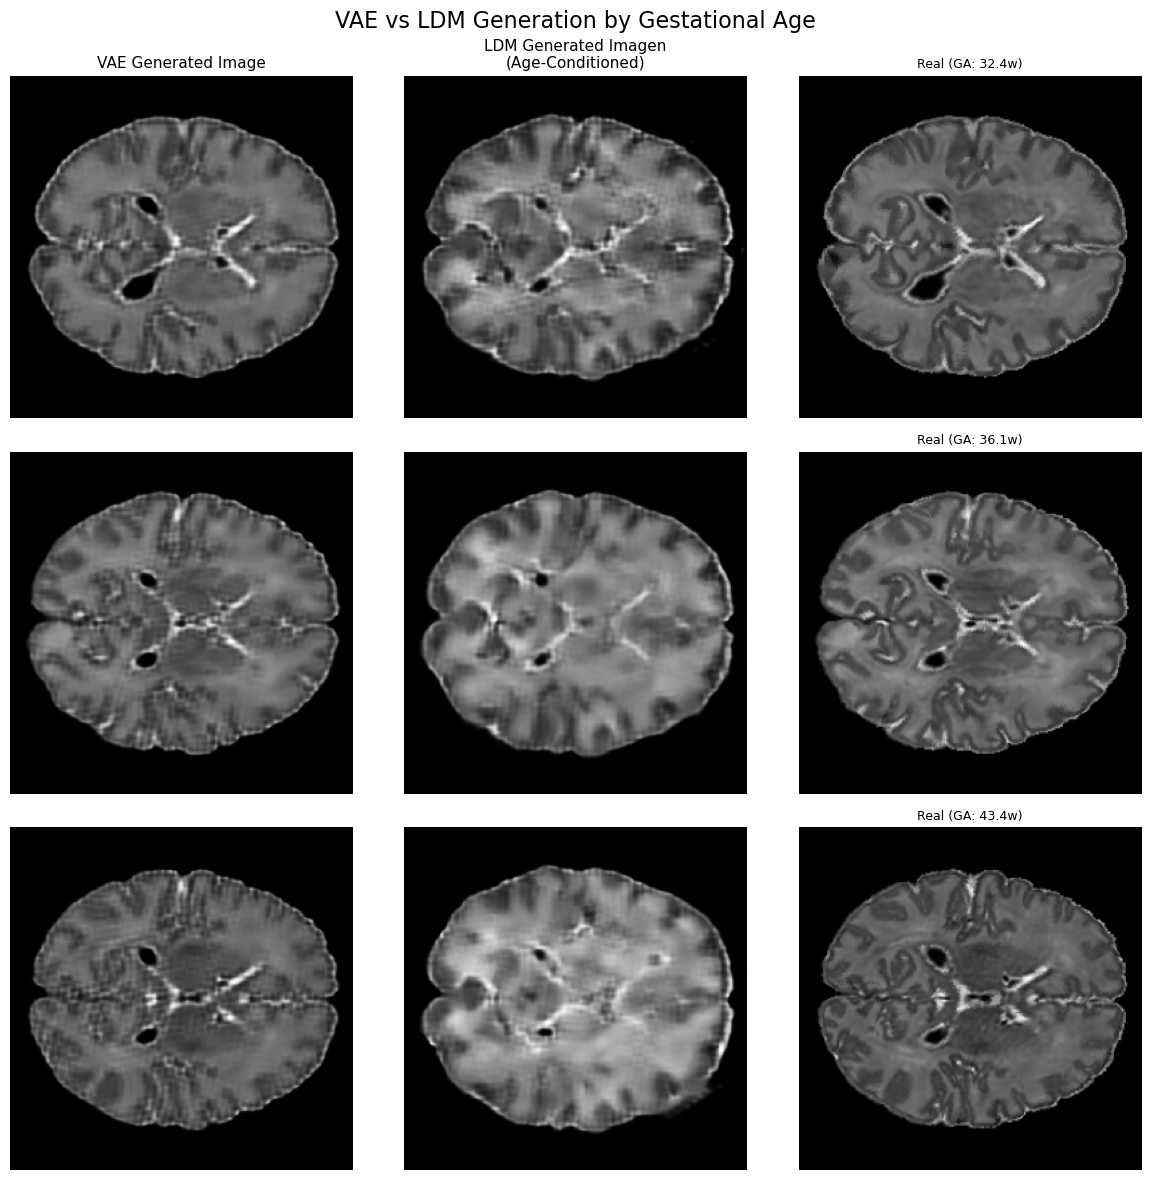

In [24]:
# Here I will compare the VAE and LDM generated samples side by side
VAEmodel.eval()
diffusion_model.eval()
DDPM_final = DDPM_Scheduler(num_time_steps=1000).to(device)

# I pick three evenly spaced age samples and put them in a list
test_ages = np.linspace(float(label_dataset['Age'].min()),float(label_dataset['Age'].max()),3).tolist()

# Here I get all the test images and labels then I try to find the closest match per age
all_test_images = []
all_test_ages = []
with torch.no_grad():
    for data, labels in test_loader:
        all_test_images.append(data)
        all_test_ages.append(labels)

all_test_images = torch.cat(all_test_images, dim=0)  # (N, 1, 256, 256)
all_test_ages = torch.cat(all_test_ages, dim=0)       # (N,)

def get_closest_real_image(target_age, all_images, all_ages):
    # I then try to find the real test image whose age is closest to target_age
    diffs = (all_ages - target_age).abs()
    closest_idx = diffs.argmin().item()
    actual_age = all_ages[closest_idx].item()
    return all_images[closest_idx], actual_age

# Next plotting the graphs; three columns
fig, axes = plt.subplots(len(test_ages), 3, figsize=(12, 4 * len(test_ages)))
fig.suptitle("VAE vs LDM Generation by Gestational Age", fontsize=16)

col_titles = ["VAE Generated Image",
              "LDM Generated Imagen\n(Age-Conditioned)",
              "Closest Real Image"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11)

with torch.no_grad():
    for i, target_age in enumerate(test_ages):

        # Find nearest real image to target age
        real_img, actual_age = get_closest_real_image(
            target_age, all_test_images, all_test_ages
        )

        # 2. VAE reconstruction of real image
        _, vae_recon, _, _ = VAEmodel(real_img.unsqueeze(0).to(device))


        # Second is the LDM
        ldm_generated_img = generate_brain_image(
            diffusion_model=diffusion_model,
            VAEmodel=VAEmodel,
            scheduler=DDPM_final,
            age_label=float(target_age) / 40.0,
            latent_mean=latent_mean,
            latent_std=latent_std,
            latent_shape=(1, 32, 32, 32),
            num_time_steps=1000,
            device=device
        )

        # I find the closest real image
        real_img, actual_age = get_closest_real_image(target_age, all_test_images, all_test_ages)

        axes[i, 0].imshow(vae_recon[0, 0].cpu(), cmap='gray')
        axes[i, 0].set_ylabel(f'GA: {target_age:.1f}w', fontsize=10)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(ldm_generated_img[0, 0].cpu(), cmap='gray')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(real_img[0].cpu(), cmap='gray')
        axes[i, 2].set_title(f'Real (GA: {actual_age:.1f}w)', fontsize=9)
        axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

**Comparison**

Compared to the real test images, both models produced plausible outputs, the real image shows sharper contrast and more precise tissue details which neither models were able to replicate. The VAE reconstruction was able to produce the gross structure similar to the real image but has blurring particularly at the brain folds. The LDM is able to generate images which shows brain foldings and general patterns such as ventricles but is less sharp compared to the VAE reconstruction at finer details.
 In summary, VAE reconstruction is closer to the real image in terms of structure and is more sharp compared to LDM generated images.
